# Superstore Business Performance Analysis
### Executive Summary
**Prepared by:** Phillip Altidor  
**Date:** June 6,2026  
**Dataset:** Sample Superstore | 9,993 transactions | 793 customers | 2014–2017


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

sns.set_theme(style='whitegrid')

df = pd.read_csv('../data/processed/superstore_cleaned.csv', parse_dates=['Order Date', 'Ship Date'], dtype={'Postal Code': 'string'})
rfm = pd.read_csv('../data/processed/rfm_segments.csv')


This analysis examines 4 years of Superstore transactional data (2014–2017) 
across 9,993 transactions, 793 customers, and 3 product categories. 

The business is **growing in revenue and total profit**, but profitability is uneven. 
Margin weakened slightly in 2017 and profit leakage is concentrated in 
high-discount transactions, Furniture/Tables, and the Central region.

Three critical problems were identified:
1. **Over-discounting** — 14% of transactions carry 30%+ discounts and generate net losses
2. **Furniture profitability** — Tables sub-category alone lost $17,725
3. **Customer retention risk** — a large share of customers show weak recent engagement by RFM scoring


In [2]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
overall_margin = (total_profit / total_sales * 100)
total_customers = rfm.shape[0]
inactive_customers = (rfm['Segment'] == 'Inactive / Low Value').sum()

print(f"Total Sales:       ${total_sales:>12,.2f}")
print(f"Total Profit:      ${total_profit:>12,.2f}")
print(f"Overall Margin:    {overall_margin:>11.2f}%")
print(f"Total Customers:   {total_customers:>12,}")
print(f"Inactive / Low Value Customers: {inactive_customers:>5,} ({inactive_customers/total_customers*100:.1f}%)")


Total Sales:       $2,296,919.49
Total Profit:      $  286,409.08
Overall Margin:          12.47%
Total Customers:            793
Inactive / Low Value Customers:   351 (44.3%)


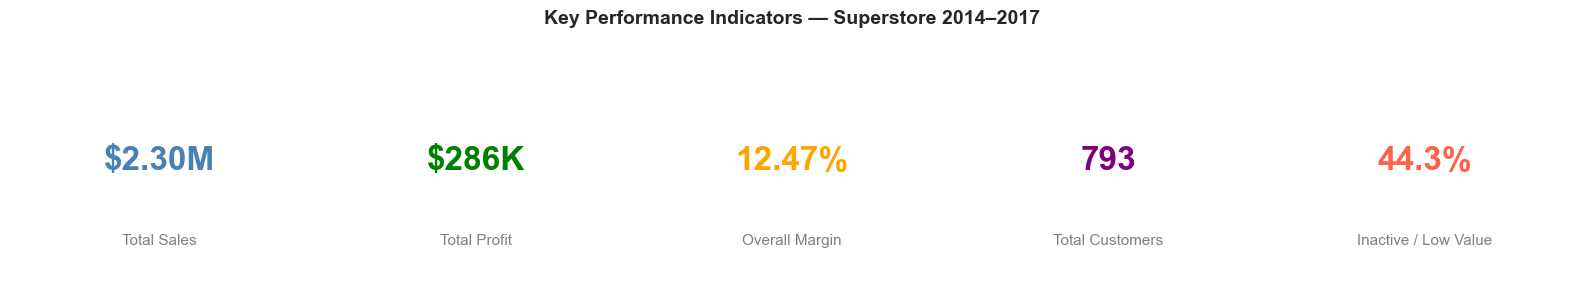

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(16, 3))

kpis = [
    ('Total Sales', '$2.30M', 'steelblue'),
    ('Total Profit', '$286K', 'green'),
    ('Overall Margin', '12.47%', 'orange'),
    ('Total Customers', '793', 'purple'),
    ('Inactive / Low Value', '44.3%', 'tomato')
]

for ax, (label, value, color) in zip(axes, kpis):
    ax.text(0.5, 0.6, value, ha='center', va='center', 
            fontsize=24, fontweight='bold', color=color,
            transform=ax.transAxes)
    ax.text(0.5, 0.25, label, ha='center', va='center',
            fontsize=11, color='gray', transform=ax.transAxes)
    ax.axis('off')

plt.suptitle('Key Performance Indicators — Superstore 2014–2017', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/05_kpi_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()


## Revenue & Margin Trend (2014–2017)

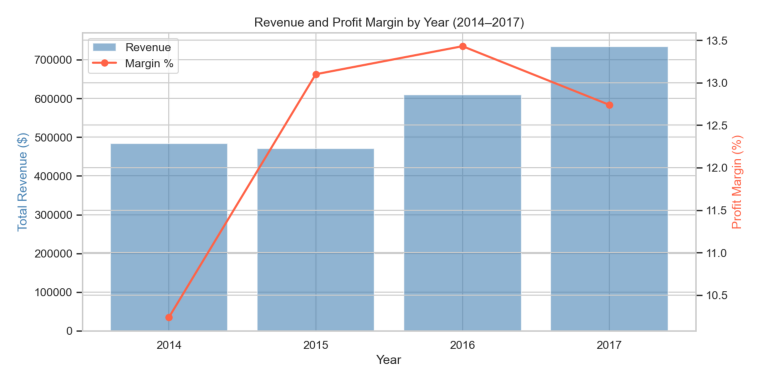

In [4]:
img = mpimg.imread('../outputs/figures/03_yoy_trend.png')
fig, ax = plt.subplots(figsize=(10, 4))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

Revenue grew year-over-year from $484K (2014) to $733K (2017). Profit margin peaked at 13.43% in 2016 then dipped to 12.74% in 2017 — signalling that growth is beginning to outpace profitability.

## Finding 1: Over-Discounting is Destroying Profit


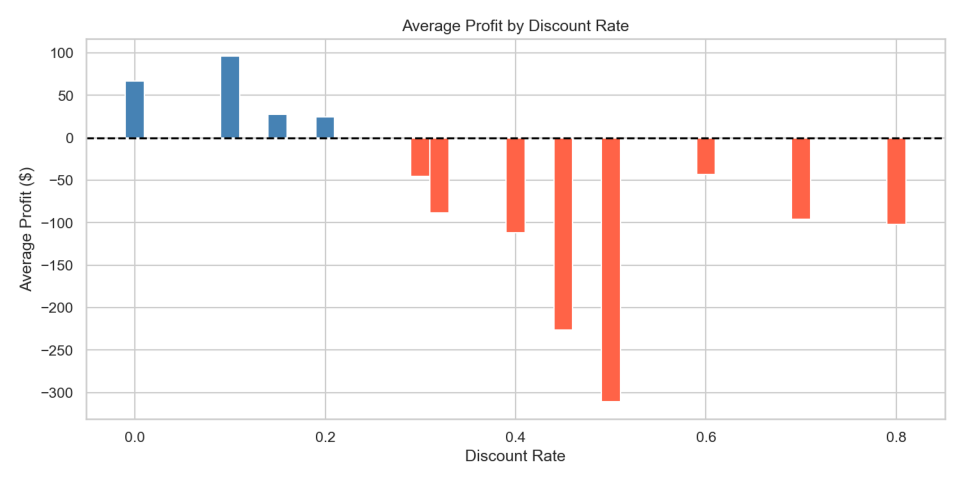

In [5]:
img = mpimg.imread('../outputs/figures/03_avg_profit_by_discount.png')
fig, ax = plt.subplots(figsize=(10, 5))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()


- Discount and profit have a **-0.22 correlation** — higher discounts are associated with lower profit
- Break-even threshold is **between 20–30% discount** — average profit turns negative at 30%
- 1,392 transactions (14%) with 30%+ discount generated **-$135,364 in net losses**
- **OLS regression** (controlling for Category, Region, Sales, and Quantity) confirms discount is a statistically significant negative predictor of profit — see Notebook 3, Section 7 for full model output
- **Recommendation:** Pilot a 20% discount cap. Measure sales volume, margin, and profit impact before company-wide rollout.

## Finding 2: Furniture — High Revenue, Failing Margins


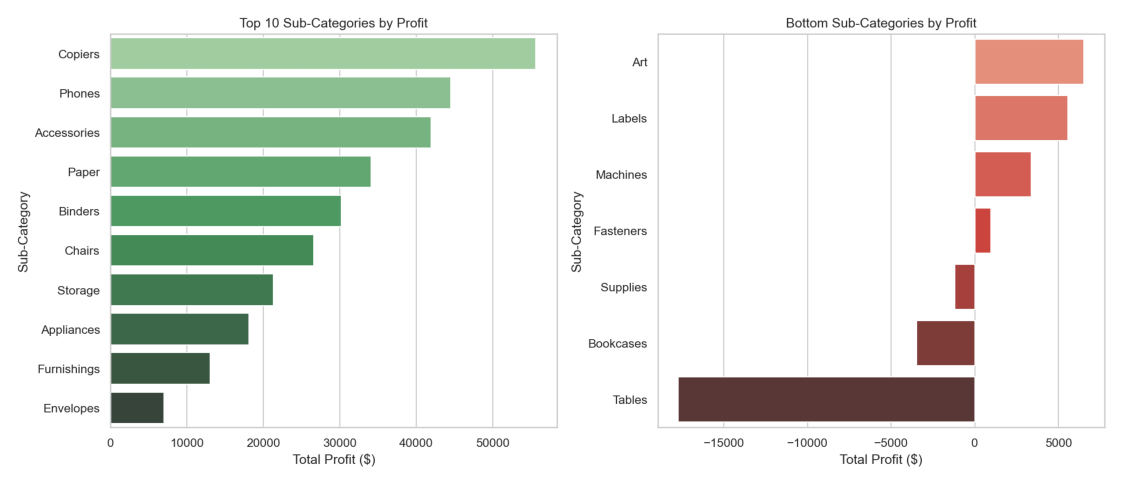

In [6]:
img = mpimg.imread('../outputs/figures/02_subcategory_profit.png')
fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()


- Furniture generates $741K in sales but only **2.49% profit margin**
- Tables sub-category lost **-$17,725** — the worst performing product line
- Bookcases also unprofitable at **-$3,472**
- Furniture has the highest loss rate at **33.6%** — 1 in 3 transactions loses money
- **Recommendation:** Immediate pricing review on Tables. Cap Furniture discounts at 15%.


## Finding 3: Customer Retention Crisis


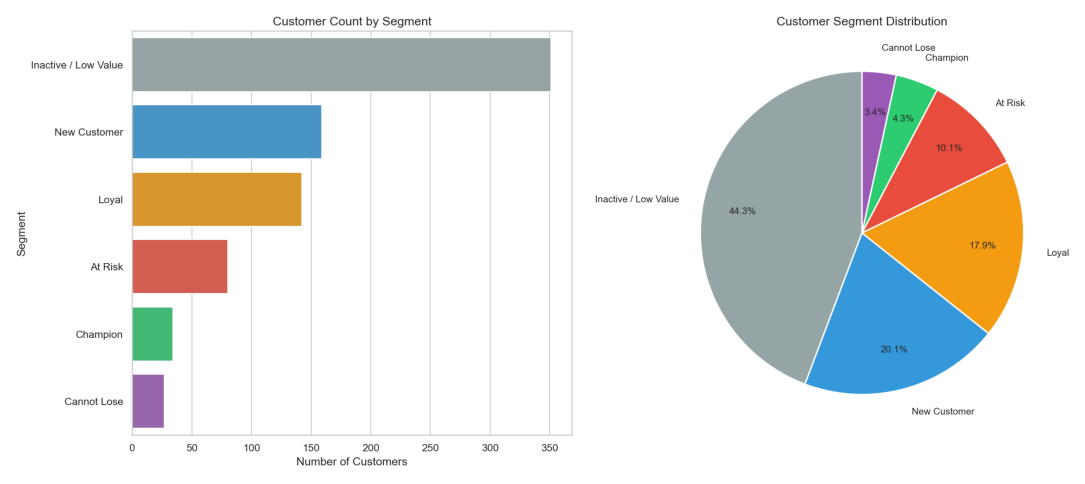

In [7]:
img = mpimg.imread('../outputs/figures/04_customer_segments.png')
fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()


- The largest customer group shows weak recent engagement by RFM scoring
- At Risk and Cannot Lose customers represent high-value retention opportunities
- Champions average **$5,863 spend** and bought within the last 16 days
- Customer status is based on historical RFM behavior, not a confirmed churn label
- **Recommendation:** Launch retention campaign for At Risk/Cannot Lose customers. 
  Create VIP program for Champions. Build onboarding sequence for New Customers.


## Strategic Recommendations

| Priority | Action | Expected Impact | Confidence | Next Validation |
|---|---|---|---|---|
| High | Test 20% discount approval cap | Protect margin on high-discount orders | Medium | A/B test or region pilot |
| High | Launch At Risk/Cannot Lose retention campaign | Protect high-value customer revenue | Medium | Track repeat purchase and margin lift |
| Medium | Conduct Tables pricing review | Address -$17,725 loss in top revenue category | High | Review SKU-level price/discount rules |
| Medium | Audit Central region discount approvals | Central discounts at 24% vs West at 10.93% | High | Compare approval patterns by manager/team |
| Low | Build Champion VIP retention program | Protect top customers averaging $5,863 spend | Medium | Measure retention and incremental profit |
| Low | Create New Customer onboarding sequence | Convert new customers to repeat buyers | Medium | Track second-purchase rate |

## Conclusion

The Superstore business is growing, but profit quality is uneven. The main issue is not total demand; 
it is concentrated margin leakage from aggressive discounting, Furniture/Tables losses, and weak 
recent engagement among a large share of customers.

The next step is to test discount controls and retention campaigns through pilots, then measure 
whether profit improves without materially reducing sales volume.
